In [184]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from patsy import dmatrices

from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.metrics import confusion_matrix,precision_score,\
                            recall_score,f1_score,\
                            classification_report, accuracy_score,\
                            precision_recall_curve,\
                            roc_curve,auc, roc_auc_score,\
                            ConfusionMatrixDisplay,\
                            root_mean_squared_error   
from sklearn.linear_model import LogisticRegression
import math
#====================================
import tensorflow as tf
import h5py
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras import initializers
import visualkeras


from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model
# layers
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Normalization,BatchNormalization
#CNN


#callbacks
from tensorflow.keras.callbacks import EarlyStopping

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

In [185]:
# ✅ Step 1: Build file path
filename = "embedded_system_network_security_dataset.csv"
file_path = os.path.join(os.getcwd(), filename)
# ✅ Step 2: Check if file exists
if not os.path.exists(file_path):
    raise FileNotFoundError(f"❌ Dataset not found at: {file_path}")

# ✅ Step 3: Load dataset
df = pd.read_csv(file_path)
print("📂 Dataset loaded successfully!")
#print(df.head())

📂 Dataset loaded successfully!


In [186]:
# Check for null values
null_counts = df.isnull().sum()
print("\n🔍 Null value counts per column:\n", null_counts)

if null_counts.sum() > 0:
    print("\n Null values detected. Consider handling them (drop/fill).")
else:
    print("\n No null values found.")



🔍 Null value counts per column:
 packet_size              0
inter_arrival_time       0
src_port                 0
dst_port                 0
packet_count_5s          0
mean_packet_size         0
spectral_entropy         0
frequency_band_energy    0
label                    0
protocol_type_TCP        0
protocol_type_UDP        0
src_ip_192.168.1.2       0
src_ip_192.168.1.3       0
dst_ip_192.168.1.5       0
dst_ip_192.168.1.6       0
tcp_flags_FIN            0
tcp_flags_SYN            0
tcp_flags_SYN-ACK        0
dtype: int64

 No null values found.


#### Dataset summary statistics

In [187]:
print("\n📊 Dataset summary statistics:\n")
# print(df.describe(include="all"))


📊 Dataset summary statistics:



####  replace True/False with 1/0 in the specified columns

In [188]:
# Columns to update
cols = [
    "protocol_type_TCP", "protocol_type_UDP",
    "src_ip_192.168.1.2", "src_ip_192.168.1.3",
    "dst_ip_192.168.1.5", "dst_ip_192.168.1.6",
    "tcp_flags_FIN", "tcp_flags_SYN", "tcp_flags_SYN-ACK"
]

# Apply map to each column
for col in cols:
    df[col] = df[col].map({True: 1, False: 0})


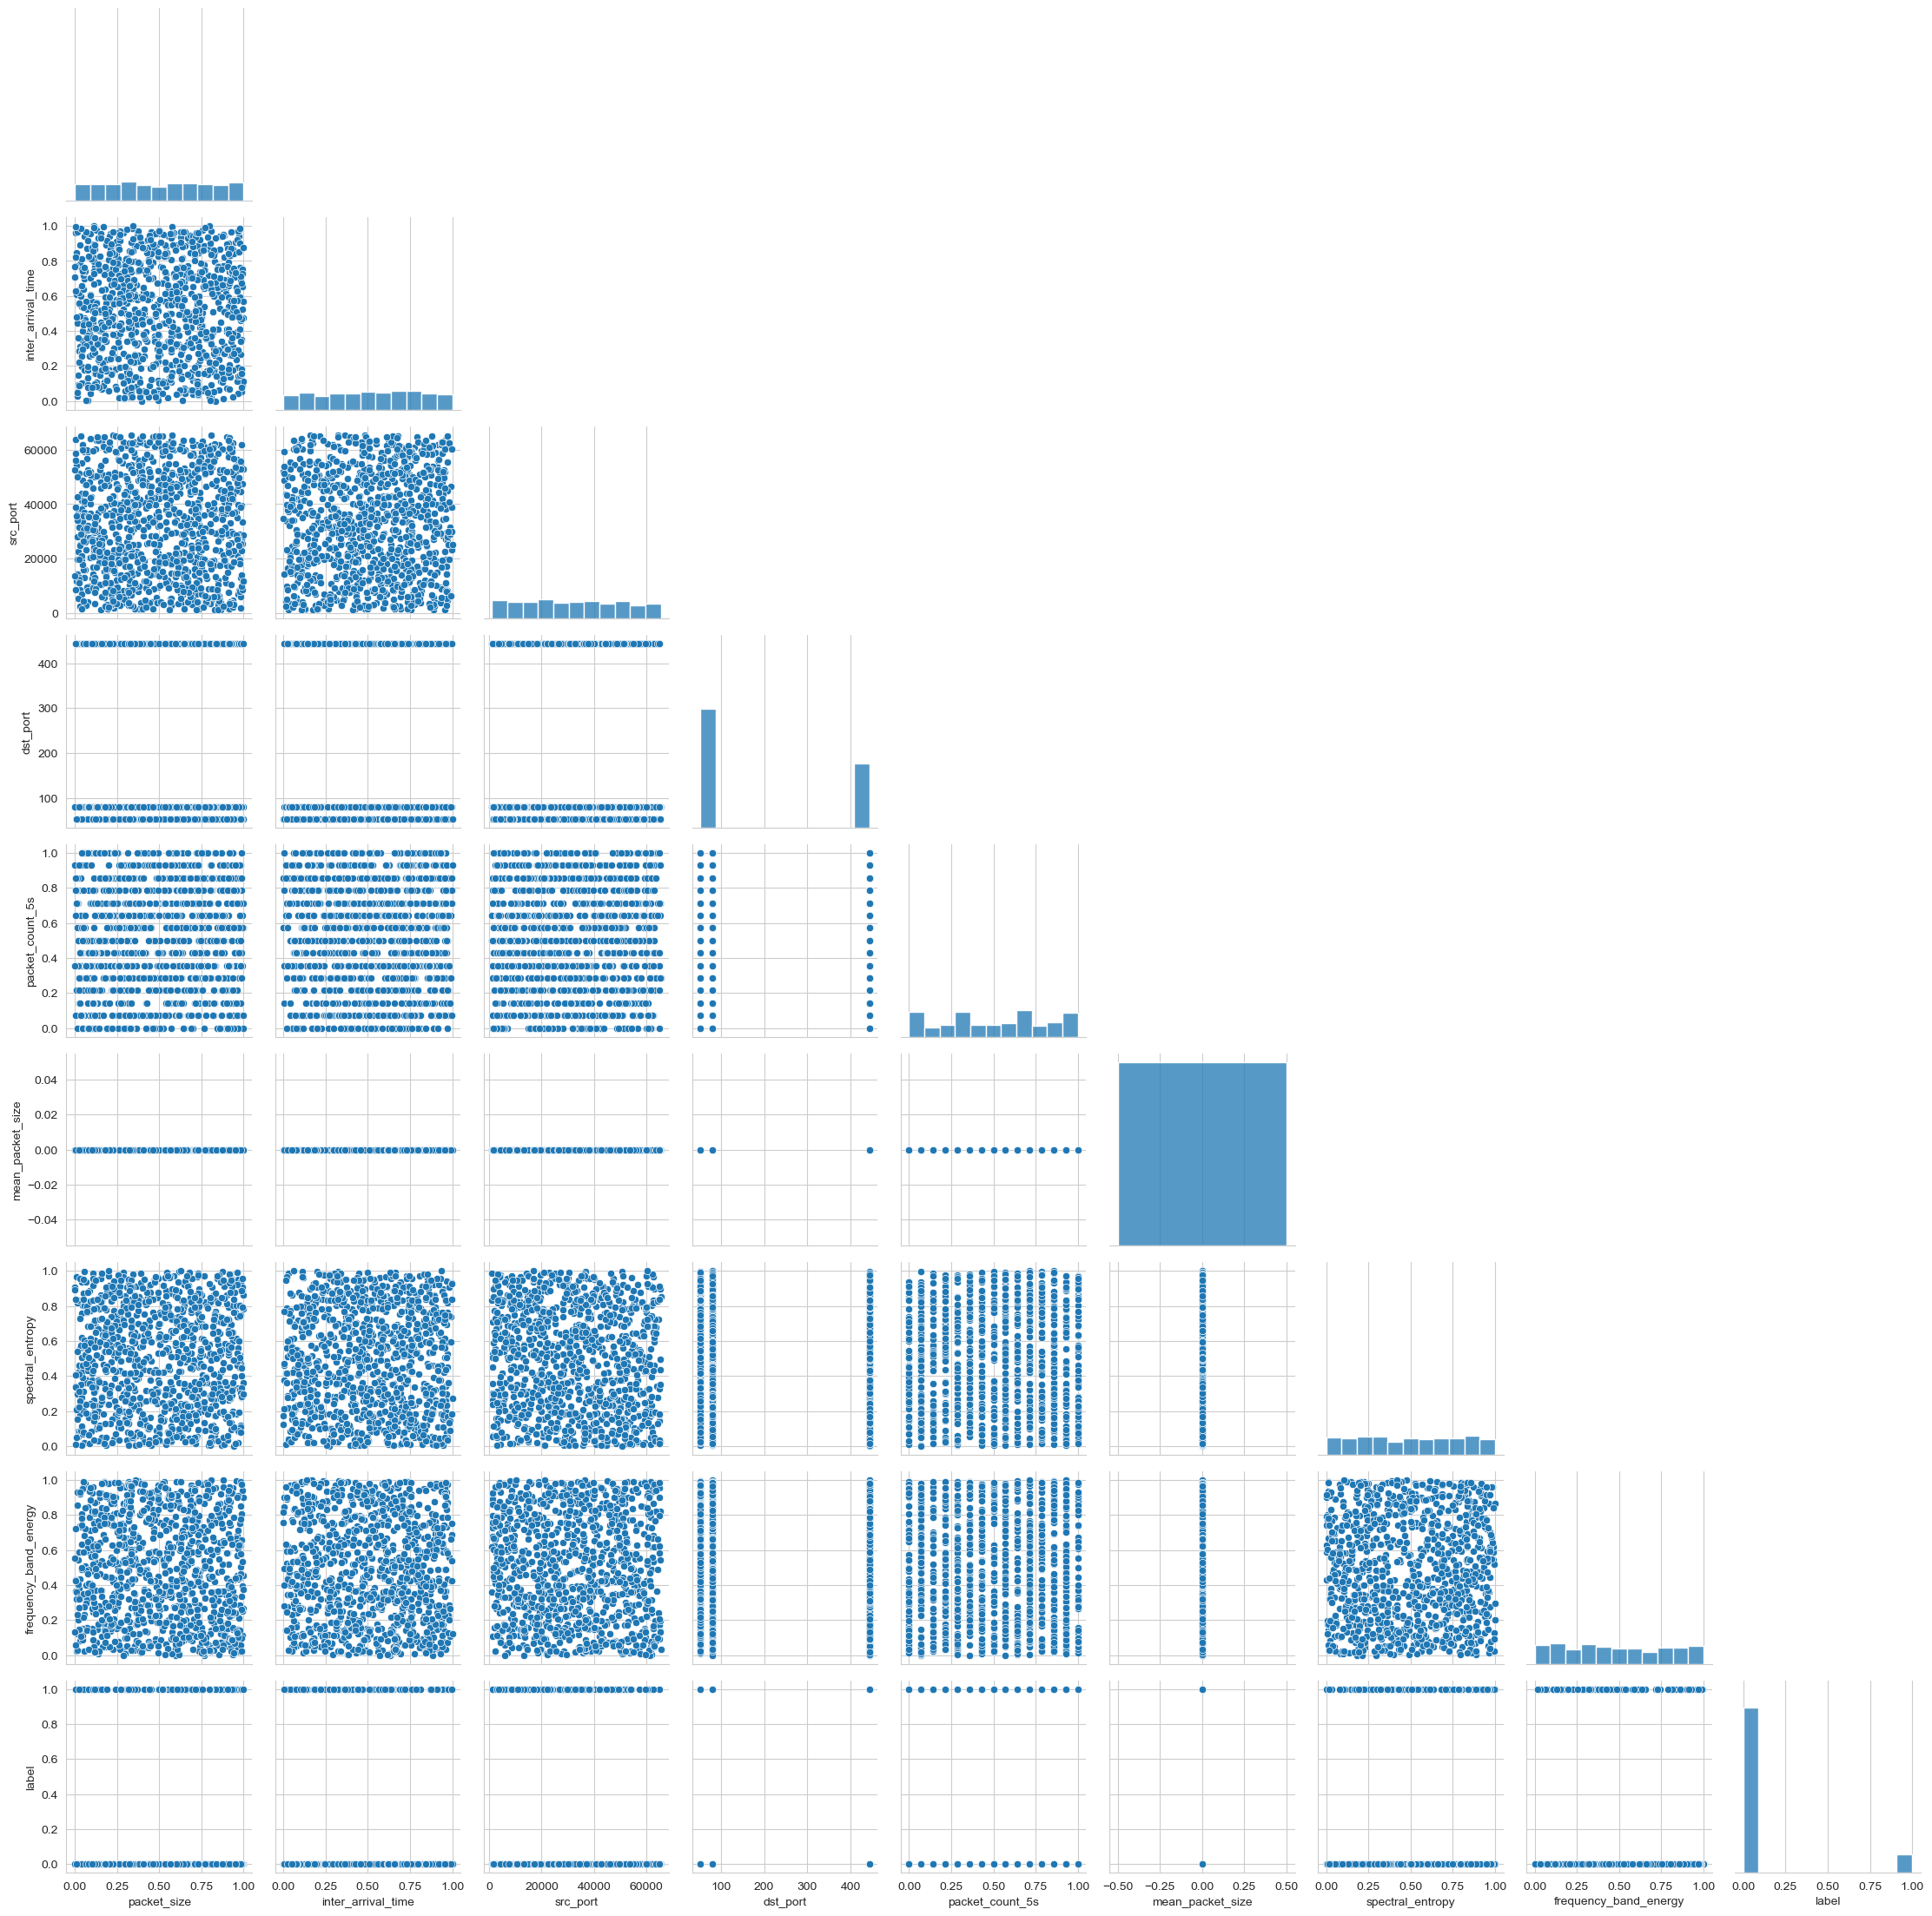

In [189]:
# Matrix Plot
cols = [
    "protocol_type_TCP", "protocol_type_UDP",
    "src_ip_192.168.1.2", "src_ip_192.168.1.3",
    "dst_ip_192.168.1.5", "dst_ip_192.168.1.6",
    "tcp_flags_FIN", "tcp_flags_SYN", "tcp_flags_SYN-ACK"
]
# Matrix Plot (lower triangle + diagonals only)
g = sns.PairGrid(df.drop(columns=cols), corner=True)
g.map_diag(sns.histplot)
g.map_lower(sns.scatterplot)

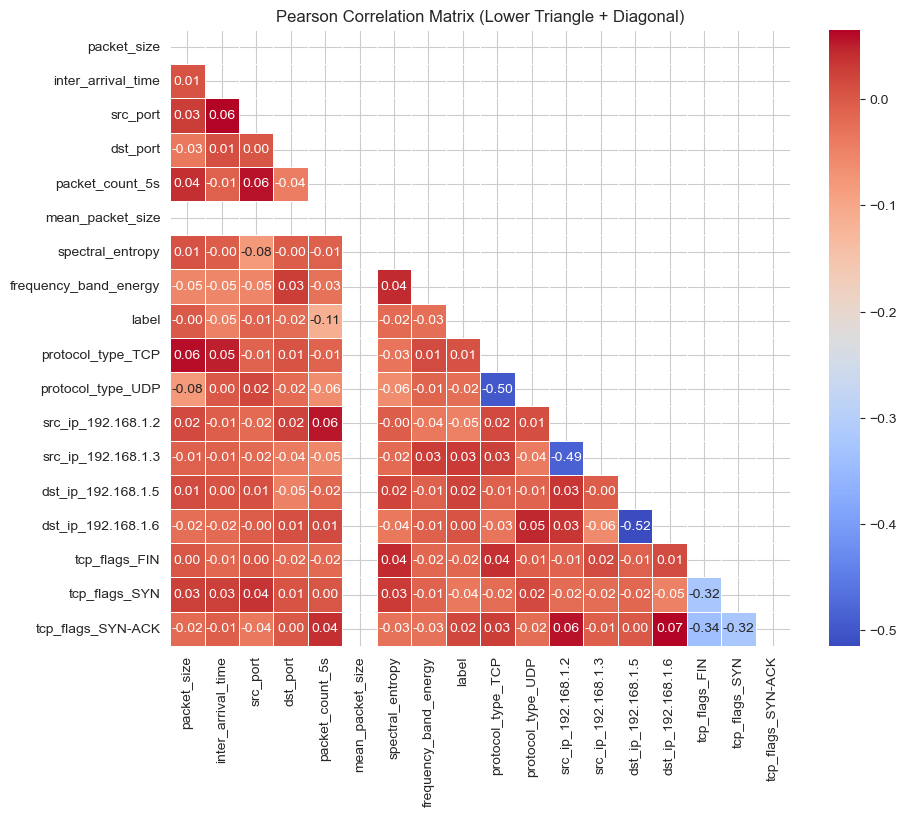

In [190]:
# Step 1: Compute Pearson correlation matrix
corr = df.corr(method="pearson")

# Step 2: Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Step 3: Plot heatmap (lower triangle + diagonal only)
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr, 
    mask=mask, 
    cmap="coolwarm", 
    annot=True, 
    fmt=".2f", 
    linewidths=0.5
)
plt.title("Pearson Correlation Matrix (Lower Triangle + Diagonal)")
plt.show()


#### Mutually Exclusive Features: 

The **strongest correlations** are negative and exist between one-hot encoded dummy variables.
- dst_ip_192.168.1.5 and dst_ip_192.168.1.6 (*-0.52*)
- protocol_type_TCP and protocol_type_UDP (*-0.50*)
- src_ip_192.168.1.2 and src_ip_192.168.1.3 (*-0.49*)

**Weak Feature-to-Feature Relationships**: Almost all continuous numerical variables (like packet_size, inter_arrival_time, and spectral_entropy) have correlations near zero (-0.10 to 0.06). They do not share linear relationships.

In [191]:
# Binary feature columns
cols = [
    "protocol_type_TCP", "protocol_type_UDP",
    "src_ip_192.168.1.2", "src_ip_192.168.1.3",
    "dst_ip_192.168.1.5", "dst_ip_192.168.1.6",
    "tcp_flags_FIN", "tcp_flags_SYN", "tcp_flags_SYN-ACK"
]

# Group by label and sum binary features
agg_result = df.groupby("label")[cols].sum()
print(df['label'].value_counts())
print("🔎 Aggregated counts of binary features by label:\n")
print(agg_result)

label
0.0    900
1.0    100
Name: count, dtype: int64
🔎 Aggregated counts of binary features by label:

       protocol_type_TCP  protocol_type_UDP  src_ip_192.168.1.2  \
label                                                             
0.0                  279                323                 291   
1.0                   32                 32                  25   

       src_ip_192.168.1.3  dst_ip_192.168.1.5  dst_ip_192.168.1.6  \
label                                                               
0.0                   300                 300                 308   
1.0                    38                  37                  35   

       tcp_flags_FIN  tcp_flags_SYN  tcp_flags_SYN-ACK  
label                                                   
0.0              228            216                227  
1.0               23             19                 28  


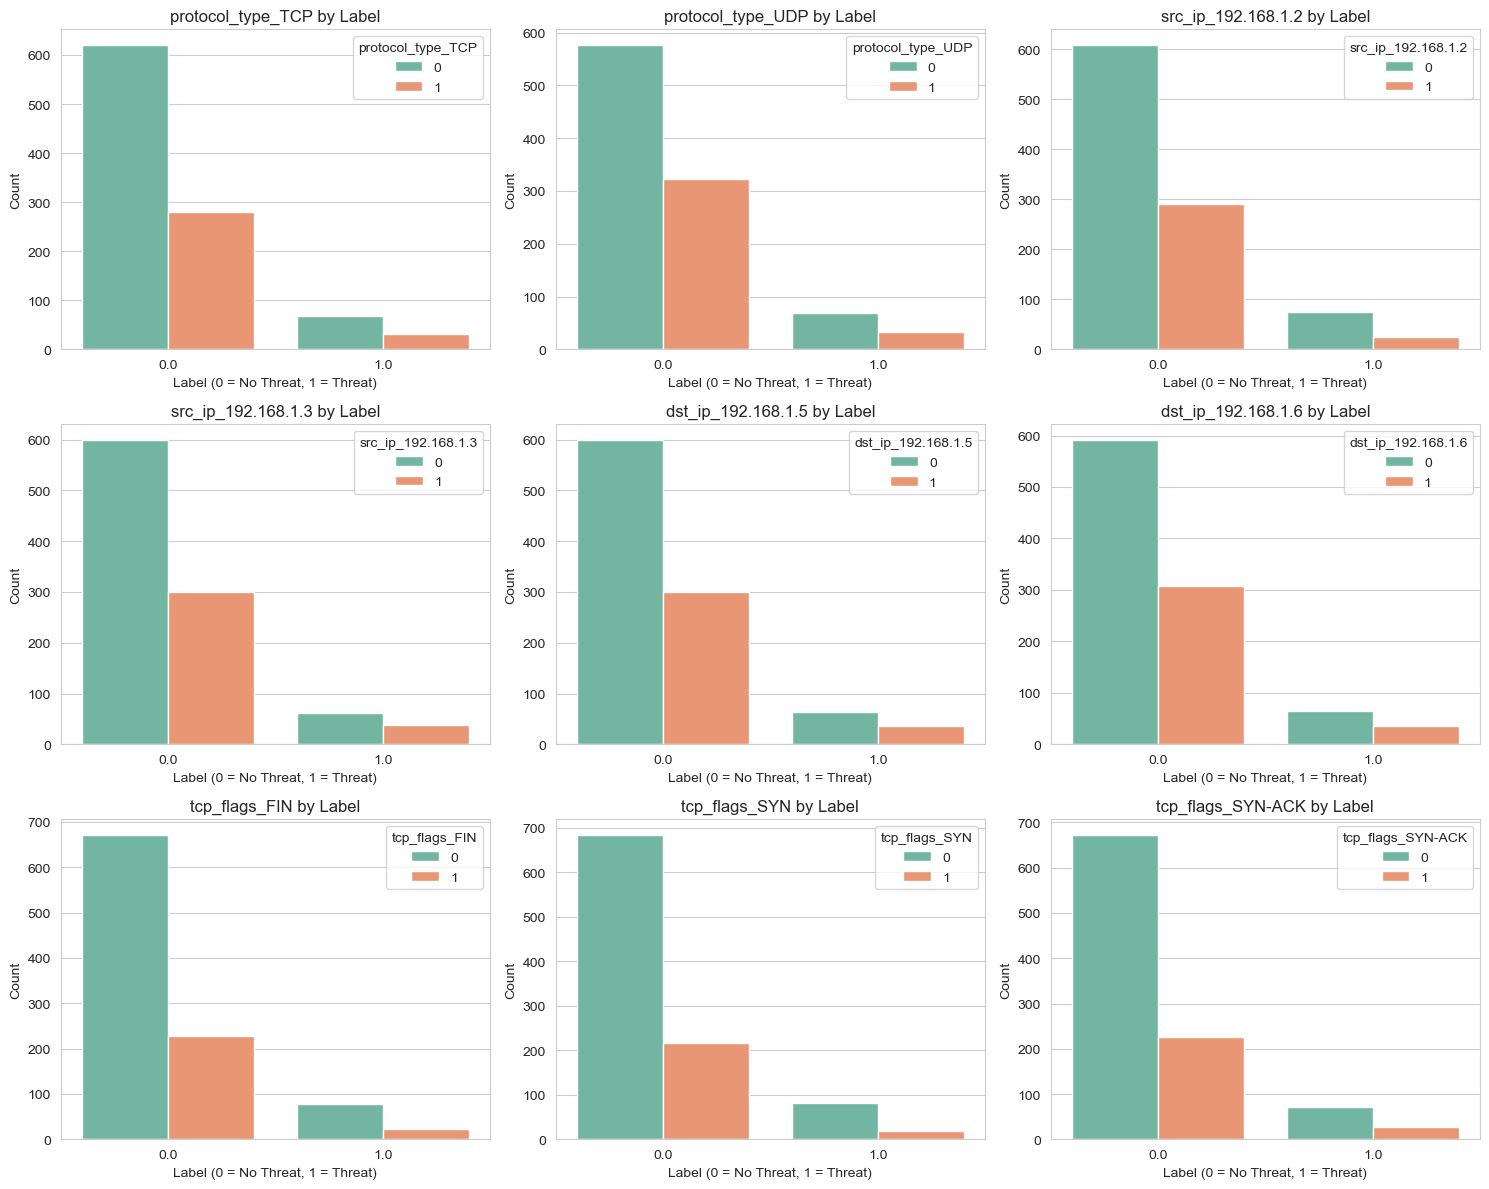

In [192]:
# Binary feature columns
cols = [
    "protocol_type_TCP", "protocol_type_UDP",
    "src_ip_192.168.1.2", "src_ip_192.168.1.3",
    "dst_ip_192.168.1.5", "dst_ip_192.168.1.6",
    "tcp_flags_FIN", "tcp_flags_SYN", "tcp_flags_SYN-ACK"
]

# Create 3x3 subplot grid
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()  # flatten to 1D array for easy iteration

# Loop through variables and plot
for i, col in enumerate(cols):
    sns.countplot(data=df, x="label", hue=col, palette="Set2", ax=axes[i])
    axes[i].set_title(f"{col} by Label")
    axes[i].set_xlabel("Label (0 = No Threat, 1 = Threat)")
    axes[i].set_ylabel("Count")
    axes[i].legend(title=col, labels=["0", "1"])

# Adjust layout
plt.tight_layout()
plt.show()


Look at the orange bars (value = 1) under Label = 0.0 (No Threat) across all four plots. They soar all the way to ~600, while the green bars (value = 0) are much lower (around 200–300).

- What an XOR value of 1 means: Exactly one of the mutually exclusive flags is active (e.g., a packet is strictly TCP or UDP, but not both or neither).
- The Insight: Normal network traffic strictly follows proper protocol standards. Safe traffic almost always satisfies the exclusive XOR condition (1).

Look closely at the Protocol XOR plot (top left):

- For No Threat (0.0): The standard-abiding orange packets outnumber anomalous green packets by a massive 2:1 ratio (600 vs 300).
- For Threat (1.0): The anomalous green packets catch up drastically, making the ratio nearly 1:1 (roughly 40 vs 60).

C:\Users\TODO\AppData\Local\Temp\ipykernel_32804\969390103.py:36: UserWarning: Glyph 8853 (\N{CIRCLED PLUS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\TODO\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8853 (\N{CIRCLED PLUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


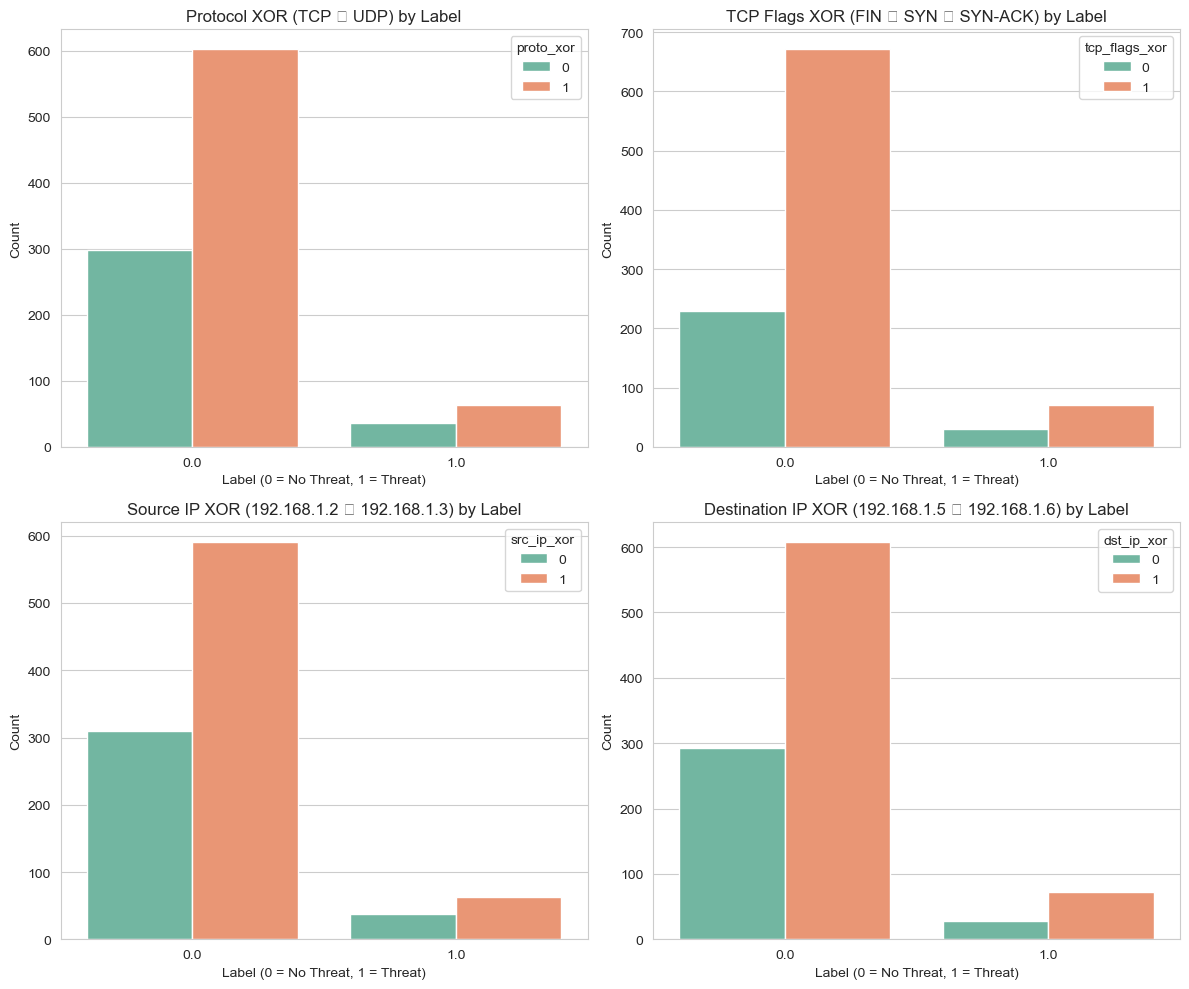

In [193]:
# ✅ Define XOR features
df["proto_xor"] = df["protocol_type_TCP"] ^ df["protocol_type_UDP"]
df["tcp_flags_xor"] = df["tcp_flags_FIN"] ^ df["tcp_flags_SYN"] ^ df["tcp_flags_SYN-ACK"]
df["src_ip_xor"] = df["src_ip_192.168.1.2"] ^ df["src_ip_192.168.1.3"]
df["dst_ip_xor"] = df["dst_ip_192.168.1.5"] ^ df["dst_ip_192.168.1.6"]

# ✅ Create 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Plot each XOR feature vs label
sns.countplot(data=df, x="label", hue="proto_xor", palette="Set2", ax=axes[0])
axes[0].set_title("Protocol XOR (TCP ⊕ UDP) by Label")
axes[0].set_xlabel("Label (0 = No Threat, 1 = Threat)")
axes[0].set_ylabel("Count")
axes[0].legend(title="proto_xor", labels=["0", "1"])

sns.countplot(data=df, x="label", hue="tcp_flags_xor", palette="Set2", ax=axes[1])
axes[1].set_title("TCP Flags XOR (FIN ⊕ SYN ⊕ SYN-ACK) by Label")
axes[1].set_xlabel("Label (0 = No Threat, 1 = Threat)")
axes[1].set_ylabel("Count")
axes[1].legend(title="tcp_flags_xor", labels=["0", "1"])

sns.countplot(data=df, x="label", hue="src_ip_xor", palette="Set2", ax=axes[2])
axes[2].set_title("Source IP XOR (192.168.1.2 ⊕ 192.168.1.3) by Label")
axes[2].set_xlabel("Label (0 = No Threat, 1 = Threat)")
axes[2].set_ylabel("Count")
axes[2].legend(title="src_ip_xor", labels=["0", "1"])

sns.countplot(data=df, x="label", hue="dst_ip_xor", palette="Set2", ax=axes[3])
axes[3].set_title("Destination IP XOR (192.168.1.5 ⊕ 192.168.1.6) by Label")
axes[3].set_xlabel("Label (0 = No Threat, 1 = Threat)")
axes[3].set_ylabel("Count")
axes[3].legend(title="dst_ip_xor", labels=["0", "1"])

plt.tight_layout()
plt.show()


In [194]:
# Define the engineered XOR column names based on your chart
xor_cols = ['proto_xor', 'tcp_flags_xor', 'src_ip_xor', 'dst_ip_xor']

print("=== RISK PROBABILITIES PER XOR VALUE ===\n")

for col in xor_cols:
    print(f"--- Feature: {col} ---")
    
    # Calculate P(Threat | XOR Value)
    # This groups by the XOR state (0 or 1) and calculates the percentage of Threats (Label=1)
    prob = df.groupby(col)['label'].mean() * 100
    
    # Calculate how much risk increases when XOR is 0 vs 1
    p_threat_given_0 = prob.get(0, 0)
    p_threat_given_1 = prob.get(1, 0)
    
    print(f"Probability of Threat if Anomalous (XOR = 0): {p_threat_given_0:.2f}%")
    print(f"Probability of Threat if Standard  (XOR = 1): {p_threat_given_1:.2f}%")
    
    if p_threat_given_1 > 0:
        risk_multiplier = p_threat_given_0 / p_threat_given_1
        print(f"👉 Risk Multiplier: Traffic is {risk_multiplier:.1f}x more likely to be a threat if XOR is 0.")
    print("\n")


=== RISK PROBABILITIES PER XOR VALUE ===

--- Feature: proto_xor ---
Probability of Threat if Anomalous (XOR = 0): 10.78%
Probability of Threat if Standard  (XOR = 1): 9.61%
👉 Risk Multiplier: Traffic is 1.1x more likely to be a threat if XOR is 0.


--- Feature: tcp_flags_xor ---
Probability of Threat if Anomalous (XOR = 0): 11.58%
Probability of Threat if Standard  (XOR = 1): 9.45%
👉 Risk Multiplier: Traffic is 1.2x more likely to be a threat if XOR is 0.


--- Feature: src_ip_xor ---
Probability of Threat if Anomalous (XOR = 0): 10.69%
Probability of Threat if Standard  (XOR = 1): 9.63%
👉 Risk Multiplier: Traffic is 1.1x more likely to be a threat if XOR is 0.


--- Feature: dst_ip_xor ---
Probability of Threat if Anomalous (XOR = 0): 8.75%
Probability of Threat if Standard  (XOR = 1): 10.59%
👉 Risk Multiplier: Traffic is 0.8x more likely to be a threat if XOR is 0.




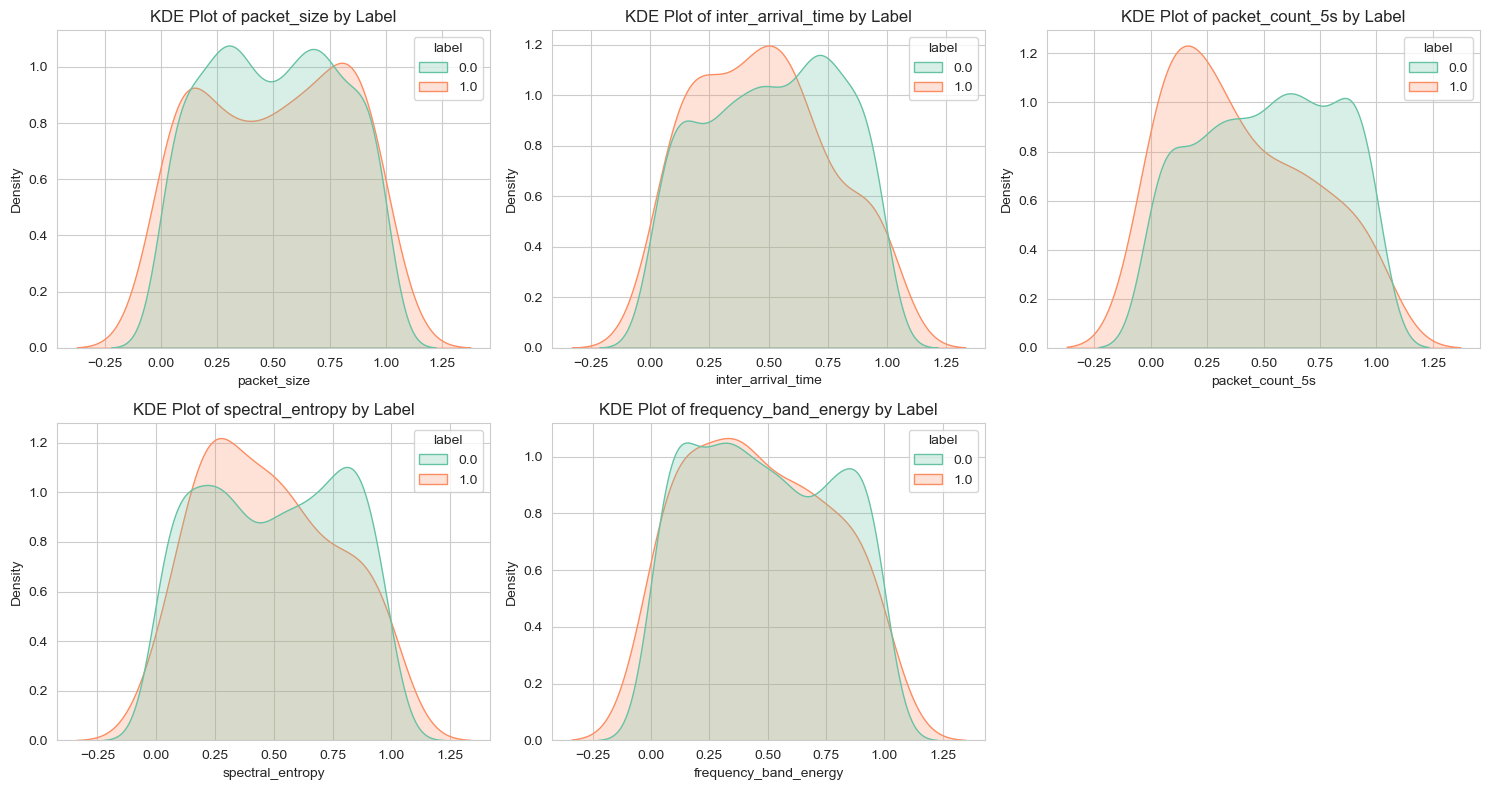

In [195]:
import seaborn as sns
import matplotlib.pyplot as plt

# ✅ Corrected float feature columns (use underscores if needed)
float_cols = [
    'packet_size', 'inter_arrival_time', 'packet_count_5s',
    'spectral_entropy', 'frequency_band_energy'
]

# Create subplot grid (2x3 for compact layout)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

# Loop through float columns
for i, col in enumerate(float_cols):
    sns.kdeplot(
        data=df, x=col, hue="label",
        fill=True, common_norm=False, palette="Set2", ax=axes[i]
    )
    axes[i].set_title(f"KDE Plot of {col} by Label")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Density")

# Remove unused subplot if number of cols < grid size
for j in range(len(float_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


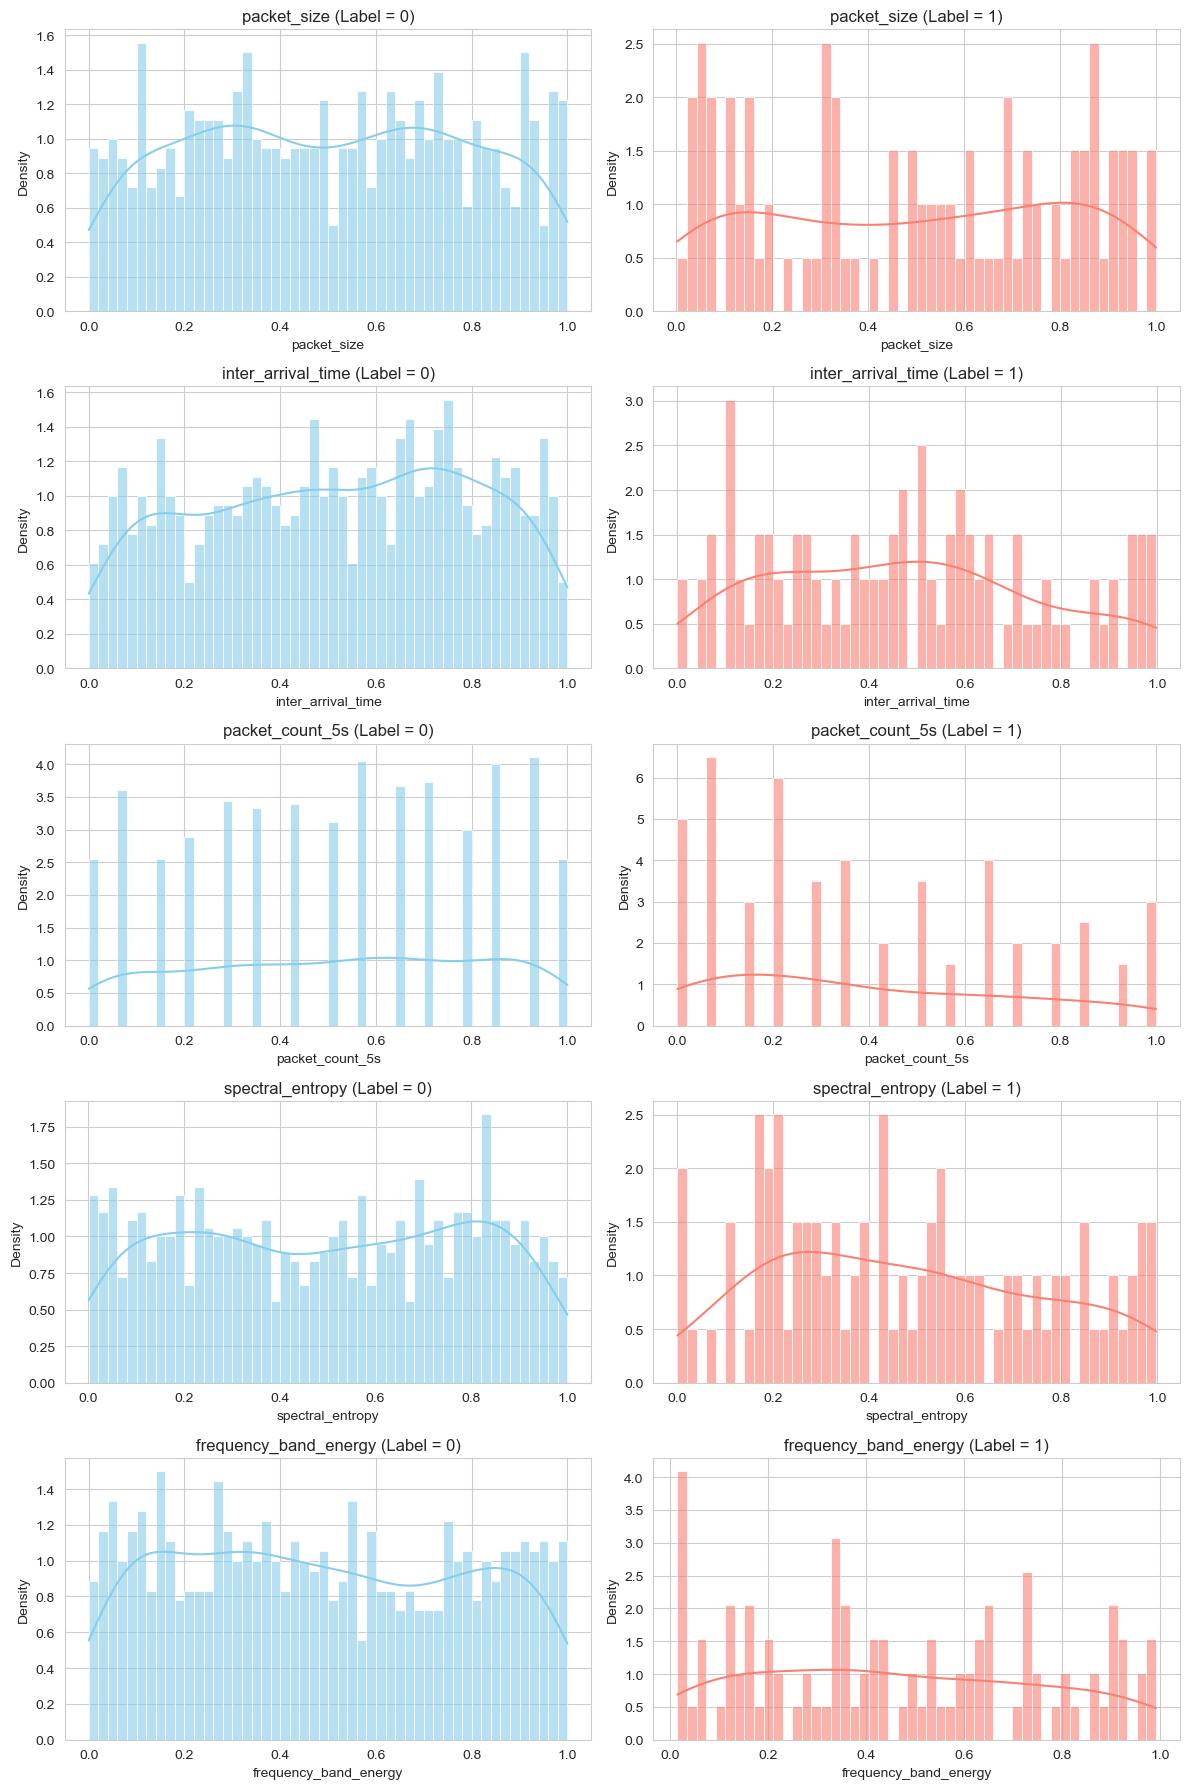

In [196]:
# Float feature columns
float_cols = [
    'packet_size', 'inter_arrival_time', 'packet_count_5s',
    'spectral_entropy', 'frequency_band_energy'
]

# Create subplot grid (rows = number of features, cols = 2 for label 0 & 1)
fig, axes = plt.subplots(len(float_cols), 2, figsize=(12, 18))

# Loop through float columns
for i, col in enumerate(float_cols):
    # Label = 0
    sns.histplot(
        data=df[df["label"] == 0], x=col,
        kde=True, stat="density", bins=50,
        color="skyblue", ax=axes[i, 0], alpha=0.6
    )
    axes[i, 0].set_title(f"{col} (Label = 0)")
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel("Density")

    # Label = 1
    sns.histplot(
        data=df[df["label"] == 1], x=col,
        kde=True, stat="density", bins=50,
        color="salmon", ax=axes[i, 1], alpha=0.6
    )
    axes[i, 1].set_title(f"{col} (Label = 1)")
    axes[i, 1].set_xlabel(col)
    axes[i, 1].set_ylabel("Density")

plt.tight_layout()
plt.show()


#### Visible relationships:

While most variables are uniformly distributed across both classes, packet_count_5s and frequency_band_energy exhibit distinct distribution shifts when a threat is present.

#### Variables with Strong/Visible Shifts (Predictive Signals):

- frequency_band_energy (High Predictive Value):
    - No Threat (Label = 0): The distribution is stable and fairly uniform across the entire range (0.0 to 1.0).
    - Threat Present (Label = 1): There is a massive, sharp spike at the absolute lowest end (near 0.0) where density exceeds 4.0, along with a secondary spike around 0.35.
    - Relationship: Malicious traffic is strongly associated with very low or specific bursts of frequency band energy.

- packet_count_5s (Moderate Predictive Value):
    - No Threat (Label = 0): Evenly distributed and high across all ranges from 0.0 to 1.0.
    - Threat Present (Label = 1): The distribution significantly skews to the left. The highest densities (peaks up to 6.0) happen at the lower end (0.0 to 0.2) and taper off toward 1.0.
    - Relationship: Threat traffic tends to consist of lower packet counts within a 5-second window compared to normal traffic.

#### Variables with Weak/No Clear Shift:
packet_size, inter_arrival_time, spectral_entropy

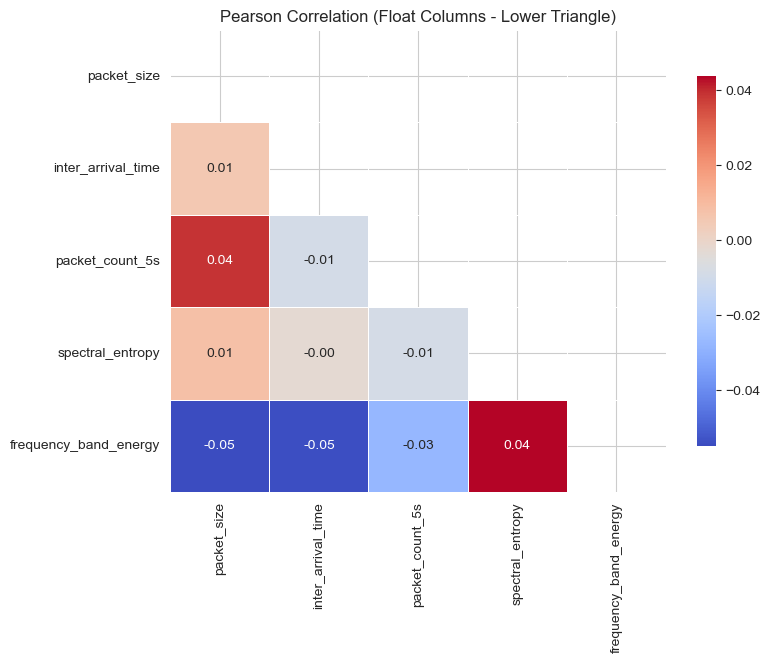

In [197]:
# ✅ Float feature columns
float_cols = [
    'packet_size', 'inter_arrival_time', 'packet_count_5s',
    'spectral_entropy', 'frequency_band_energy'
]

# ✅ Step 1: Compute correlation matrix for float columns only
corr = df[float_cols].corr(method="pearson")

# ✅ Step 2: Create mask for upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# ✅ Step 3: Plot heatmap (lower triangle + diagonal only)
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Pearson Correlation (Float Columns - Lower Triangle)")
plt.show()


#### Apply stabderd scalling and tuning dataset for models

In [198]:
df = df.drop(columns=['proto_xor', 'tcp_flags_xor', 'src_ip_xor', 'dst_ip_xor'])

# ✅ Rename columns
df = df.rename(columns={
    'packet_size': 'pkt_sz',
    'inter_arrival_time': 'intr_arv_tm',
    'packet_count_5s': 'pkt_cnt',
    'mean_packet_size': 'mn_pkt_sz',
    'frequency_band_energy': 'frq',
    'protocol_type_TCP': 'tcp',
    'protocol_type_UDP': 'udp',
    'src_ip_192.168.1.2': 'src_2',
    'src_ip_192.168.1.3': 'src_3',
    'dst_ip_192.168.1.5': 'dst_5',
    'dst_ip_192.168.1.6': 'dst_6',
    'tcp_flags_FIN': 'tcp_fin',
    'tcp_flags_SYN': 'tcp_syn',
    'tcp_flags_SYN-ACK': 'tcp_syn_ack'
})

df.columns

Index(['pkt_sz', 'intr_arv_tm', 'src_port', 'dst_port', 'pkt_cnt', 'mn_pkt_sz',
       'spectral_entropy', 'frq', 'label', 'tcp', 'udp', 'src_2', 'src_3',
       'dst_5', 'dst_6', 'tcp_fin', 'tcp_syn', 'tcp_syn_ack'],
      dtype='object')

In [199]:

# Columns of interest
cols = [
    'pkt_sz', 'intr_arv_tm', 'src_port', 'dst_port', 'pkt_cnt', 'mn_pkt_sz',
    'spectral_entropy', 'frq', 'label', 'tcp', 'udp', 'src_2', 'src_3',
    'dst_5', 'dst_6', 'tcp_fin', 'tcp_syn', 'tcp_syn_ack'
]

# Compute min and max for each column
min_max = pd.DataFrame({
    "min": df[cols].min(),
    "max": df[cols].max()
})

# print(min_max)

# ✅ Initialize scaler
scaler = StandardScaler()

# ✅ Apply scaling on selected columns
df[['src_port', 'dst_port']] = scaler.fit_transform(df[['src_port', 'dst_port']])

# ✅ Quick check
# print(df[['src_port', 'dst_port']].head())


#### Split dataset into training and test sets

In [200]:
# ✅ Feature columns
feature_cols = [
    'pkt_sz', 'intr_arv_tm', 'src_port', 'dst_port', 'pkt_cnt', 'mn_pkt_sz',
    'spectral_entropy', 'frq', 'tcp', 'udp', 'src_2', 'src_3',
    'dst_5', 'dst_6', 'tcp_fin', 'tcp_syn', 'tcp_syn_ack'
]

# ✅ Target column
target_col = 'label'

# ✅ Split into X (features) and y (target)
X = df[feature_cols]
y = df[target_col]

# ✅ Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ✅ Quick check
print("Training set shape:", X_train.shape, y_train.shape)
print("Test set shape:", X_test.shape, y_test.shape)

Training set shape: (800, 17) (800,)
Test set shape: (200, 17) (200,)


## Model 1: Generalized Linear models

In [201]:
formula = 'label ~ pkt_sz + intr_arv_tm + src_port + dst_port + pkt_cnt + mn_pkt_sz + spectral_entropy + frq + tcp + udp + src_2 + src_3 + dst_5 + dst_6 + tcp_fin + tcp_syn + tcp_syn_ack'

# Build matrices for training set
y_train_mat, X_train_mat = dmatrices(formula, X_train.join(y_train), return_type='dataframe')
y_test_mat, X_test_mat = dmatrices(formula, X_test.join(y_test), return_type='dataframe')

# ✅ Fit GLM with binomial family (logit link)
glm_binom_logit = sm.GLM(y_train_mat, X_train_mat, family=sm.families.Binomial(link=sm.families.links.Logit()))
glm_result = glm_binom_logit.fit()

# ✅ Print summary
# print(glm_result.summary())

Test Accuracy: 90.0%


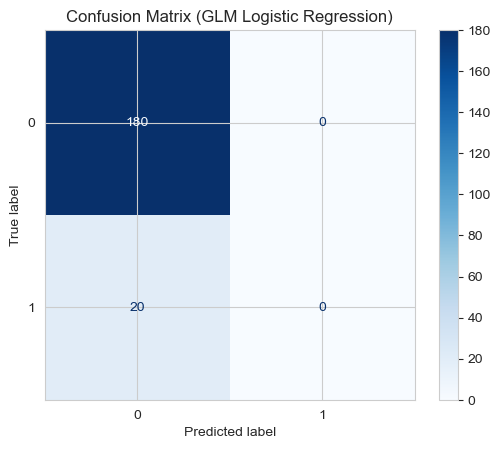

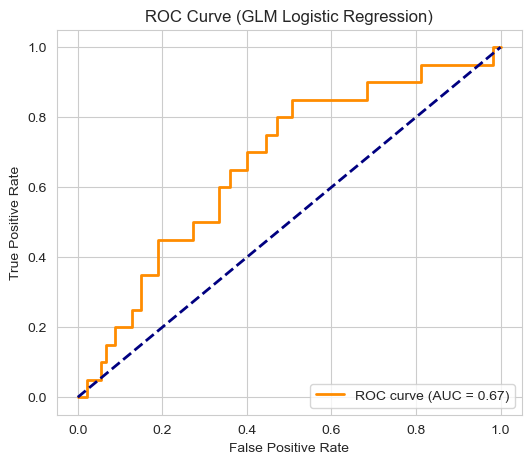

ROC-AUC Score: 0.6680555555555555


In [202]:
# ✅ Predict probabilities on test set
y_pred_prob = glm_result.predict(X_test_mat)
# ✅ Convert probabilities to class labels (threshold = 0.5)
y_pred_class = (y_pred_prob >= 0.8).astype(int)

# ✅ Calculate accuracy
accuracy = accuracy_score(y_test_mat, y_pred_class)

print(f'Test Accuracy: {accuracy*100}%')
# ✅ Confusion Matrix
cm = confusion_matrix(y_test_mat, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (GLM Logistic Regression)")
plt.show()

# ✅ ROC Curve
fpr, tpr, thresholds = roc_curve(y_test_mat, y_pred_prob)
roc_auc = roc_auc_score(y_test_mat, y_pred_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (GLM Logistic Regression)")
plt.legend(loc="lower right")
plt.show()

print("ROC-AUC Score:", roc_auc)

#### Extra code

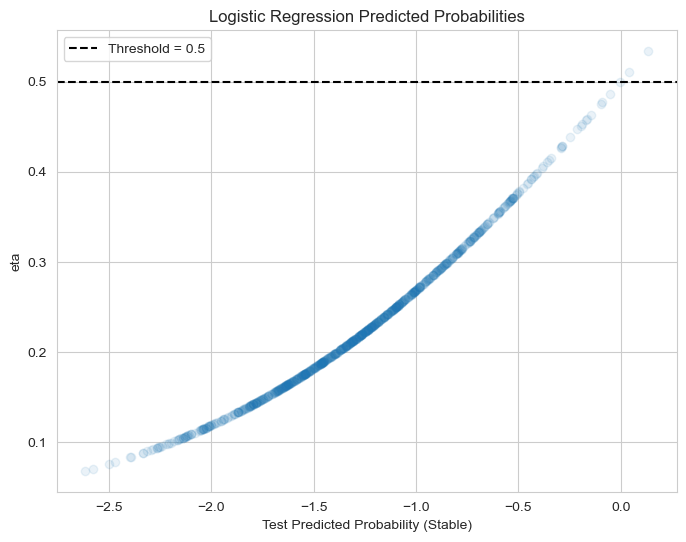

In [203]:
type(glm_result.params)
beta = glm_result.params.drop('Intercept')
intercept = 0
eta = X_train @ beta + intercept   # X@beta
prob = 1 / (1 + np.exp(-eta))
plt.figure(figsize=(8,6))
plt.scatter(x= eta, y = prob, alpha=0.09)
plt.axhline(0.5, color='black', linestyle='--', label='Threshold = 0.5')
plt.xlabel("Test Predicted Probability (Stable)")
plt.ylabel("eta")
plt.title("Logistic Regression Predicted Probabilities")
plt.legend()
plt.show()

In [204]:
# ✅ Table display function
def tableDispFormatt(results):
    print("="*80)
    print(" " * 25 + "Models Summary")
    print("="*80)
    header = f"{'Solver':<12}{'C':<8}{'l1_ratio':<10}{'ROC_AUC':<12}{'Accuracy':<12}"
    print(header)
    print("-"*80)
    for r in results:
        row = f"{r['solver']:<12}{r['C']:<8}{str(r['l1_ratio']):<10}{r['roc_auc']:<12.3f}{r['accuracy']:<12.3f}"
        print(row)
    print("="*80)

#### Model 2: Logistic Regression models with tuned hyperparameter and regularizations term

In [205]:
# ✅ Define parameter grid
C_values = [1, 10, 50, 100]
solvers = {
    "lbfgs": [0],                     # only l2 penalty
    "liblinear": [0, 1],              # l2 (0), l1 (1)
    "saga": [0, 1, 0.5, 0.8]          # l2, l1, elasticnet
}

results = []

# ✅ Loop through combinations
for solver, l1_ratios in solvers.items():
    for C in C_values:
        for l1_ratio in l1_ratios:
            # Penalty choice
            if solver == "lbfgs":
                penalty = "l2"
                l1_ratio_val = None
            elif solver == "liblinear":
                penalty = "l1" if l1_ratio == 1 else "l2"
                l1_ratio_val = None
            elif solver == "saga":
                penalty = "elasticnet" if l1_ratio not in [0, 1] else ("l1" if l1_ratio == 1 else "l2")
                l1_ratio_val = l1_ratio if penalty == "elasticnet" else None

            # ✅ Build model
            model = LogisticRegression(
                penalty=penalty,
                solver=solver,
                C=C,
                l1_ratio=l1_ratio_val,
                max_iter=10000
            )

            # ✅ Fit and predict
            model.fit(X_train, y_train)
            y_pred_prob = model.predict_proba(X_test)[:, 1]
            y_pred_class = model.predict(X_test)

            # ✅ Metrics
            acc = accuracy_score(y_test, y_pred_class)
            roc_auc = roc_auc_score(y_test, y_pred_prob)

            # ✅ Store results
            results.append({
                "solver": solver,
                "C": C,
                "l1_ratio": l1_ratio,
                "roc_auc": roc_auc,
                "accuracy": acc
            })

# ✅ Display neatly formatted table
tableDispFormatt(results)


                         Models Summary
Solver      C       l1_ratio  ROC_AUC     Accuracy    
--------------------------------------------------------------------------------
lbfgs       1       0         0.662       0.900       
lbfgs       10      0         0.668       0.900       
lbfgs       50      0         0.670       0.900       
lbfgs       100     0         0.670       0.900       
liblinear   1       0         0.662       0.900       
liblinear   1       1         0.677       0.900       
liblinear   10      0         0.668       0.900       
liblinear   10      1         0.671       0.900       
liblinear   50      0         0.668       0.900       
liblinear   50      1         0.668       0.900       
liblinear   100     0         0.668       0.900       
liblinear   100     1         0.668       0.900       
saga        1       0         0.661       0.900       
saga        1       1         0.671       0.900       
saga        1       0.5       0.668       0.900       

#### Why Accuracy and ROC‑AUC differ ?

- Accuracy (0.90):
	- Measures the proportion of correctly classified samples at a fixed threshold (usually 0.5).
	- If your dataset is imbalanced (e.g., many more negatives than positives), a model can achieve high accuracy by mostly predicting the majority class correctly.
	- Example: If 90% of samples are class 0, a model that always predicts 0 will get 90% accuracy — but it’s useless for detecting class 1.
- ROC‑AUC (0.661):
	- Measures the model’s ability to rank positive samples higher than negative ones across all thresholds.
	- AUC close to 0.5 means the model is barely better than random guessing.
	- Your score of 0.661 suggests the model struggles to separate the two classes, even though accuracy looks good at the default threshold.

#### Create sequential Models based on neural network

In [206]:
early_stop_val_loss = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
early_stop_val_acu = EarlyStopping(
    monitor='val_Accuracy',
    patience=3,
    mode='max',
    restore_best_weights=True
)

In [207]:
def display(text: str, width: int = 80):
    """
    Print text in the format ===== <text> =====
    with '=' padding so the total length equals `width`.
    
    Parameters:
        text (str): The string to display.
        width (int): Total line width (default 80).
    """
    # Core string with spaces around
    core = f" {text} "
    # Calculate padding
    pad_len = max(0, (width - len(core)) // 2)
    # Build line
    line = "=" * pad_len + core + "=" * (width - len(core) - pad_len)
    print(line)

#### Model 3: Tensor flow Neural models

In [208]:
#clear the session to reset the name counters
tf.compat.v1.reset_default_graph()
tf.random.set_seed(42)
# Build Neural Network
display('Build Neural Network')
nn_relu_softmax_xav = Sequential()
nn_relu_softmax_xav.add(keras.layers.InputLayer(shape = (X_train.shape[1],)))
nn_relu_softmax_xav.add(keras.layers.Flatten())
nn_relu_softmax_xav.add(keras.layers.Dense(units = 20,name = 'Layer20',activation="relu",
                                                     use_bias=True,kernel_initializer="glorot_uniform",
                                                     bias_initializer=initializers.Zeros()))
nn_relu_softmax_xav.add(keras.layers.Dense(units = 10,name = 'Layer10',activation="relu",
                                                     use_bias=True,kernel_initializer="glorot_uniform",
                                                     bias_initializer=initializers.Zeros()))
nn_relu_softmax_xav.add(keras.layers.Dense(units = 5,name = 'Layer5',activation="relu",
                                                     use_bias=True,kernel_initializer="glorot_uniform",
                                                     bias_initializer=initializers.Zeros()))
nn_relu_softmax_xav.add(keras.layers.Dense(units = 2,name = 'OutPut2',activation="softmax",
                                                     use_bias=True,kernel_initializer="glorot_uniform",
                                                     bias_initializer=initializers.Zeros()))


============================= Build Neural Network =============================


In [209]:
# ==============================================================================================
# Models Summary
display('Models Summary')
nn_relu_softmax_xav.summary()
# ==============================================================================================
display('Models compile')
run_eagerly_status = True
nn_relu_softmax_xav.compile(
    optimizer    = keras.optimizers.Adam(learning_rate=0.001),
    # ================ Loss & Loss weight ==========================================
    loss         = 'sparse_categorical_crossentropy',
    loss_weights = None,# assign nothing for loss weight value
    # ==============================================================================
    metrics=['SparseCategoricalAccuracy'],
    weighted_metrics=None,
    # ==============================================================================
    run_eagerly = run_eagerly_status, # how Keras executes your model internally    
    jit_compile = np.where(run_eagerly_status == True, False, True), #
    # ==============================================================================
    steps_per_execution = 1,
    auto_scale_loss = True, # Mixed precision training uses float16 or bfloat16
)

================================ Models Summary ================================


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 17)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Layer20 (Dense)                 │ (None, 20)             │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Layer10 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Layer5 (Dense)                  │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ OutPut2 (Dense)                 │ (None, 2)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 637 (2.49 KB)

 Trainable params: 637 (2.49 KB)

 Non-trainable params: 0 (0.00 B)

================================ Models compile ================================


In [210]:
# ====================================================================================================
# Train model
display('Models Train')
batch_size_  = 64
epochs_      = 100
sample_size_ = X_train.shape[0]
Validation_sample_set = X_test.shape[0]
validation_batch_size_ = batch_size_
validation_freq_ = 1
print(f'Step per epoch: {math.floor(sample_size_/batch_size_)}')
print(f'validation_steps: {math.floor(Validation_sample_set/validation_batch_size_)}')
history_nn_relu_softmax_xav = nn_relu_softmax_xav.fit(x = X_train, y = y_train, 
                    batch_size = batch_size_,
                    epochs=epochs_,
                    verbose = 1,
                    callbacks = [early_stop_val_loss], #importent for expert user
                    validation_split = 0.0,
                    validation_data  = (X_test, y_test),
                    shuffle=True,
                    class_weight  = None, # VIMP used for classification problems
                    sample_weight = None, # VIMP
                    #steps_per_epoch = math.floor(sample_size_/batch_size_),
                    #validation_steps = math.floor(Validation_sample_set/validation_batch_size_), #validation_steps_[0],                   
                    #validation_batch_size = validation_batch_size_,
                    validation_freq = validation_freq_,         
)

================================= Models Train =================================
Step per epoch: 12
validation_steps: 3
Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - SparseCategoricalAccuracy: 0.6150 - loss: 0.6473 - val_SparseCategoricalAccuracy: 0.8600 - val_loss: 0.5576
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - SparseCategoricalAccuracy: 0.8954 - loss: 0.5170 - val_SparseCategoricalAccuracy: 0.9000 - val_loss: 0.4284
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - SparseCategoricalAccuracy: 0.9063 - loss: 0.3990 - val_SparseCategoricalAccuracy: 0.9000 - val_loss: 0.3541
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - SparseCategoricalAccuracy: 0.9063 - loss: 0.3364 - val_SparseCategoricalAccuracy: 0.9000 - val_loss: 0.3360
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - SparseCategoricalAccuracy: 0.9063 - loss: 0.3196 - val_SparseCategoricalAccuracy: 0.9000 - val_loss: 0.3343
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - SparseCategorica

History Columns name: Index(['SparseCategoricalAccuracy', 'loss', 'val_SparseCategoricalAccuracy',
       'val_loss', 'epoch'],
      dtype='object')


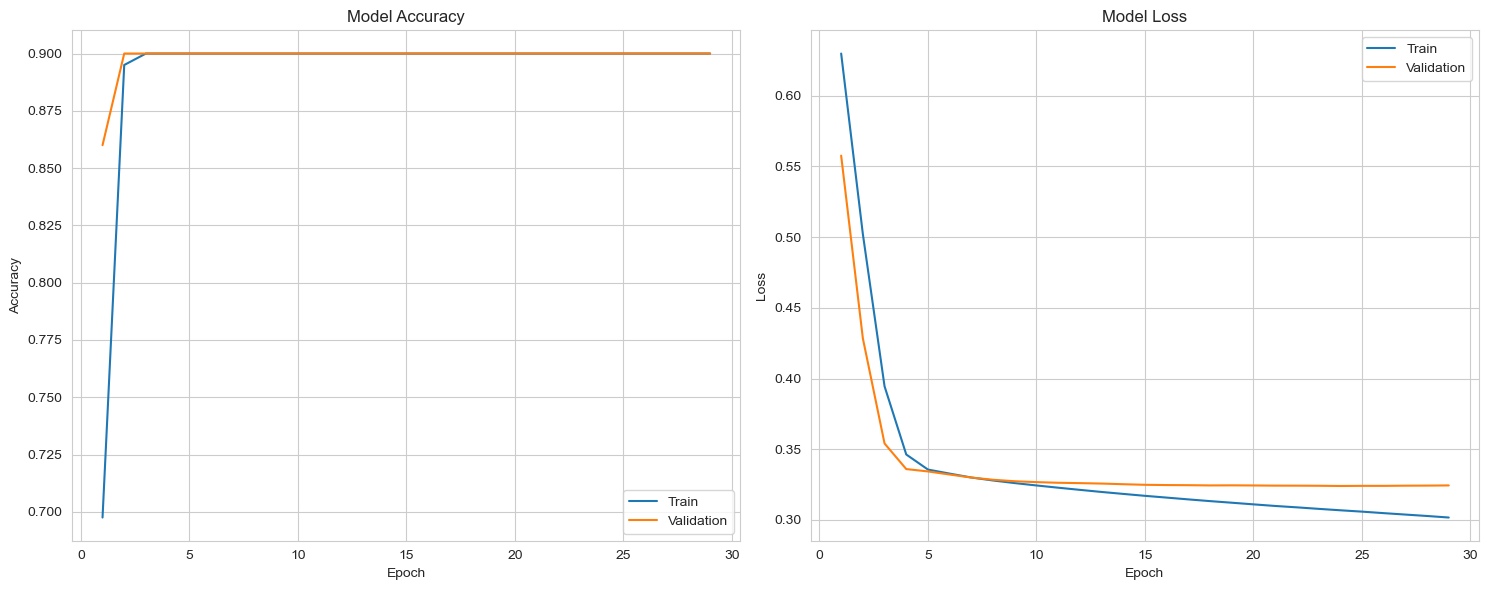

In [211]:
history_df = pd.DataFrame(history_nn_relu_softmax_xav.history)
history_df['epoch'] = history_df.index + 1
print(f'History Columns name: {history_df.columns}')
# Set Seaborn style
sns.set_style("whitegrid")

# Create 2-row, 1-column subplot layout
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Accuracy subplot ---
sns.lineplot(x="epoch", y=history_df.columns.values[0], data=history_df, label="Train", ax=axes[0])
sns.lineplot(x="epoch", y=history_df.columns.values[2], data=history_df, label="Validation", ax=axes[0])
axes[0].set_title("Model Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# --- Loss subplot ---
sns.lineplot(x="epoch", y=history_df.columns.values[1], data=history_df, label="Train", ax=axes[1])
sns.lineplot(x="epoch", y=history_df.columns.values[3], data=history_df, label="Validation", ax=axes[1])
axes[1].set_title("Model Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

Based on these training curves, model has run into a classic issue known as the Majority Class Trap, caused by severe class imbalance.

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


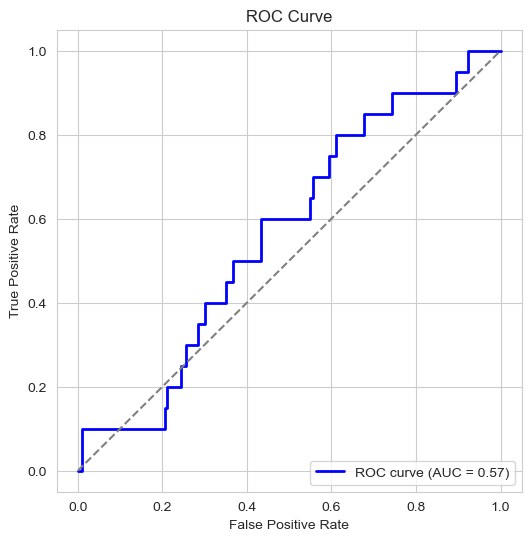

In [212]:
y_pred_proba = nn_relu_softmax_xav.predict(X_test)[:, 1]  # Use probabilities for class 1

# Convert one-hot encoded y_test_one_hot back to 1D labels
y_test_labels = y_test #y_test.argmax(axis=1)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test_labels, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

In [213]:
loss, acc = nn_relu_softmax_xav.evaluate(X_test, y_test)
print("Test Loss:", loss)
print("Test Accuracy:", acc)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - SparseCategoricalAccuracy: 0.8979 - loss: 0.3371
Test Loss: 0.32404255867004395
Test Accuracy: 0.8999999761581421


#### Model 4: Gradient boost XGb classifier

Accuracy: 0.900
ROC-AUC: 0.662


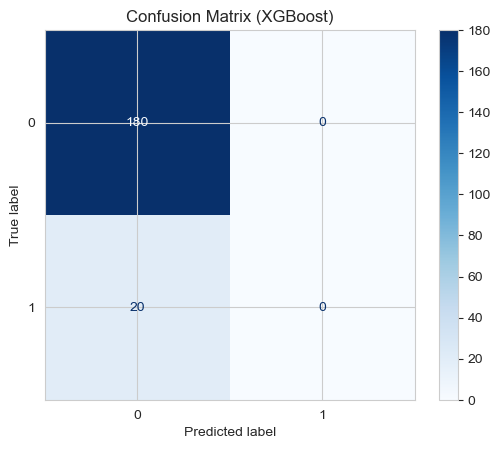

In [214]:
# ✅ Build XGBoost classifier
xgb_clf = xgb.XGBClassifier(
    objective="binary:logistic",   # binary classification
    eval_metric="logloss",         # evaluation metric
    n_estimators=55,              # number of trees
    max_depth=5,                   # tree depth
    learning_rate=0.00001,             # step size shrinkage
    subsample=0.8,                 # row sampling
    colsample_bytree=0.8,          # feature sampling
    random_state=42
)

# ✅ Train model
xgb_clf.fit(X_train, y_train)

# ✅ Predictions
y_pred_class = xgb_clf.predict(X_test)
y_pred_prob  = xgb_clf.predict_proba(X_test)[:, 1]

# ✅ Metrics
acc = accuracy_score(y_test, y_pred_class)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f"Accuracy: {acc:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")

# ✅ Confusion Matrix
cm = confusion_matrix(y_test, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (XGBoost)")
plt.show()

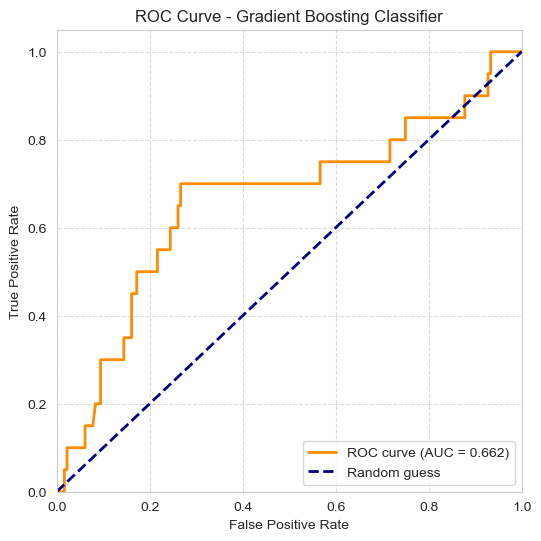

In [215]:
# ✅ Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# ✅ Plot ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color="darkorange", lw=2,
         label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random guess")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gradient Boosting Classifier")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

#### Model 5: Gradient boost CatBoost classifier

0:	total: 6.44ms	remaining: 32.2s
100:	total: 175ms	remaining: 8.51s
200:	total: 345ms	remaining: 8.24s
300:	total: 508ms	remaining: 7.93s
400:	total: 685ms	remaining: 7.85s
500:	total: 859ms	remaining: 7.71s
600:	total: 1.04s	remaining: 7.65s
700:	total: 1.23s	remaining: 7.53s
800:	total: 1.41s	remaining: 7.37s
900:	total: 1.57s	remaining: 7.17s
1000:	total: 1.75s	remaining: 6.99s
1100:	total: 1.92s	remaining: 6.8s
1200:	total: 2.1s	remaining: 6.64s
1300:	total: 2.27s	remaining: 6.47s
1400:	total: 2.45s	remaining: 6.29s
1500:	total: 2.62s	remaining: 6.11s
1600:	total: 2.8s	remaining: 5.94s
1700:	total: 2.97s	remaining: 5.75s
1800:	total: 3.16s	remaining: 5.61s
1900:	total: 3.35s	remaining: 5.46s
2000:	total: 3.52s	remaining: 5.27s
2100:	total: 3.69s	remaining: 5.1s
2200:	total: 3.87s	remaining: 4.92s
2300:	total: 4.05s	remaining: 4.76s
2400:	total: 4.25s	remaining: 4.6s
2500:	total: 4.47s	remaining: 4.46s
2600:	total: 4.71s	remaining: 4.34s
2700:	total: 4.95s	remaining: 4.21s
2800:	to

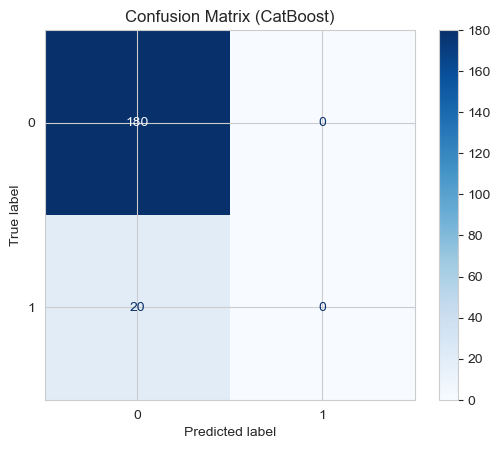

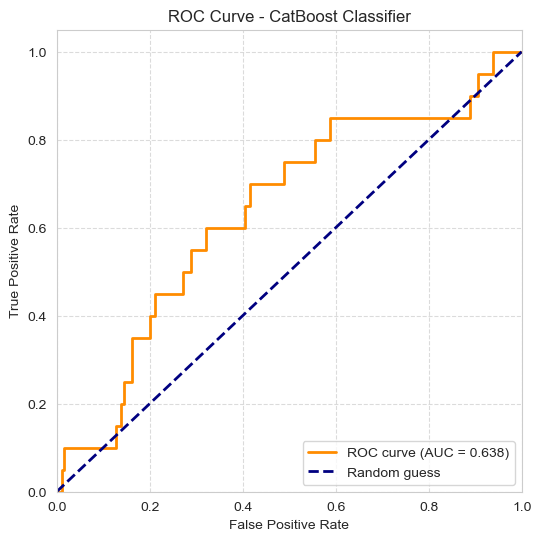

In [216]:
# ✅ Build CatBoost classifier
cat_clf = CatBoostClassifier(
    iterations=5000,          # number of boosting rounds
    learning_rate=0.0001,      # shrinkage rate
    depth=6,                 # tree depth
    loss_function="Logloss", # binary classification loss
    eval_metric="AUC",       # evaluation metric
    random_seed=42,
    verbose=100              # print training progress every 100 iterations
)

# ✅ Train model
cat_clf.fit(X_train, y_train)

# ✅ Predictions
y_pred_class = cat_clf.predict(X_test)
y_pred_prob  = cat_clf.predict_proba(X_test)[:, 1]

# ✅ Metrics
acc = accuracy_score(y_test, y_pred_class)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f"Accuracy: {acc:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")

# ✅ Confusion Matrix
cm = confusion_matrix(y_test, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (CatBoost)")
plt.show()

# ✅ ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color="darkorange", lw=2,
         label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random guess")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - CatBoost Classifier")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()


In [217]:
df.columns

Index(['pkt_sz', 'intr_arv_tm', 'src_port', 'dst_port', 'pkt_cnt', 'mn_pkt_sz',
       'spectral_entropy', 'frq', 'label', 'tcp', 'udp', 'src_2', 'src_3',
       'dst_5', 'dst_6', 'tcp_fin', 'tcp_syn', 'tcp_syn_ack'],
      dtype='object')

In [218]:
formula = 'label ~ pkt_sz + intr_arv_tm + src_port + dst_port + pkt_cnt + mn_pkt_sz + spectral_entropy + frq + tcp + udp + src_2 + src_3 + dst_5 + dst_6 + tcp_fin + tcp_syn + tcp_syn_ack'

# Build matrices for training set
y, X = dmatrices(formula, df, return_type='dataframe')


# ✅ Fit GLM with binomial family (logit link)
glm_binom_logit = sm.GLM(y, X, family=sm.families.Binomial(link=sm.families.links.Logit()))
glm_result = glm_binom_logit.fit()

In [220]:
df['label'].value_counts()

label
0.0    900
1.0    100
Name: count, dtype: int64

##### Additional try

Test Accuracy: 90.0%


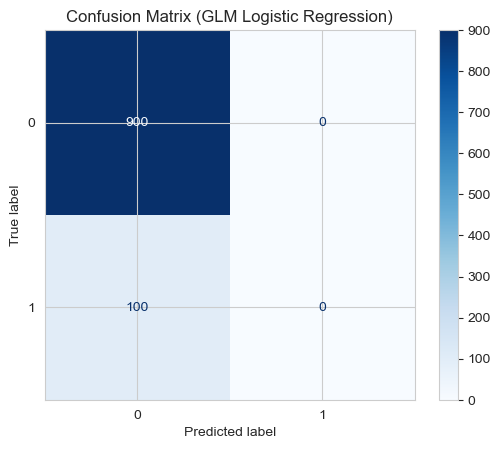

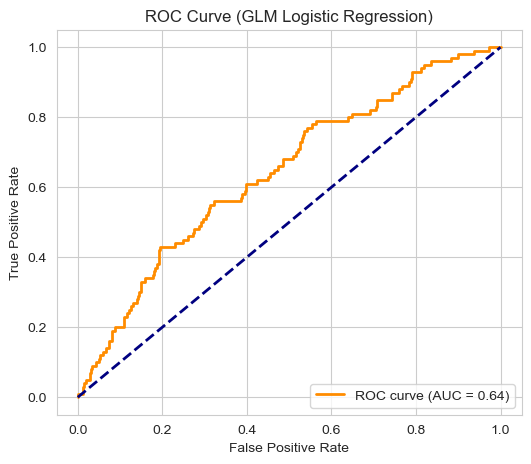

ROC-AUC Score: 0.6432


In [219]:
# ✅ Predict probabilities on test set
y_pred_prob = glm_result.predict(X)
# ✅ Convert probabilities to class labels (threshold = 0.5)
y_pred_class = (y_pred_prob >= 0.8).astype(int)

# ✅ Calculate accuracy
accuracy = accuracy_score(y, y_pred_class)

print(f'Test Accuracy: {accuracy*100}%')
# ✅ Confusion Matrix
cm = confusion_matrix(y, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (GLM Logistic Regression)")
plt.show()

# ✅ ROC Curve
fpr, tpr, thresholds = roc_curve(y, y_pred_prob)
roc_auc = roc_auc_score(y, y_pred_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (GLM Logistic Regression)")
plt.legend(loc="lower right")
plt.show()

print("ROC-AUC Score:", roc_auc)